In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from functions import F_P, GradientKernel,KernelGradientDiscrepancy
import jax_kernels as ker
from variational_inference import VariationalInference
import functions as f

import jax
from jax import random

In [2]:
device_name = "cpu"

In [3]:
c = 1
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y)))

def q_0(x):
    return jnp.exp(-jnp.linalg.norm(x)**2/2) #/ jnp.sqrt((2 *jnp.pi)**d)

def v(X):
    return -1/4 * jnp.linalg.norm(X, axis=1)**2 

def L(X):
    return jnp.mean(v(X))

k = jit(k)
q_0 = jit(q_0)
v = jit(v)
L = jit(L)


In [ ]:
eta = 0.1
T = 1000
d = 2

VI = VariationalInference(q_0,L,k,d)

# theta0 = flat_params
W0 = random.normal(random.PRNGKey(2), (1000, d))
#X0 = VI.model(Theta[0], W0)

key = random.PRNGKey(1)
Theta = VI.run(key,eta,T)
theta_fin = Theta[-1]

W_fin = random.normal(random.PRNGKey(2), (100, d))
X_fin = VI.model(theta_fin, W_fin)
X = [VI.model(theta, W0) for theta in Theta]

In [25]:
# F_P = f.F_P(q_0, L)
# k_pq = f.GradientKernel(VI.S_PQ,k)
# KGD = f.KernelGradientDiscrepancy(k_pq)

# KGD_fin = jnp.zeros(T)
# # # KDE_KGD_fin = jax.device_put(jnp.zeros(len(Eta)), device)
# # # F_P_fin = jax.device_put(jnp.zeros(len(Eta)), device)
# # # L_fin = jax.device_put(jnp.zeros(len(Eta)), device)

# for it in range(T):
#     KGD_fin = KGD_fin.at[it].set(KGD.evaluate(X[it]))
# #     # KDE_KGD_fin = KDE_KGD_fin.at[e].set(KGD.kde_KGD(X,num_samples = 300))
# #     # F_P_fin = F_P_fin.at[e].set(F_P.evaluate(X,num_samples = 300))
# #     # L_fin = L_fin.at[e].set(L(X))
    

In [26]:
# plt.plot(KGD_fin)

/var/folders/zl/0c18q_l567xgnm85cwp5t7xm0000gp/T/ipykernel_89133/1282930690.py:37: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X, Y, Z, levels=10, cmap='viridis', alpha=0.7, label='Gaussian contours')


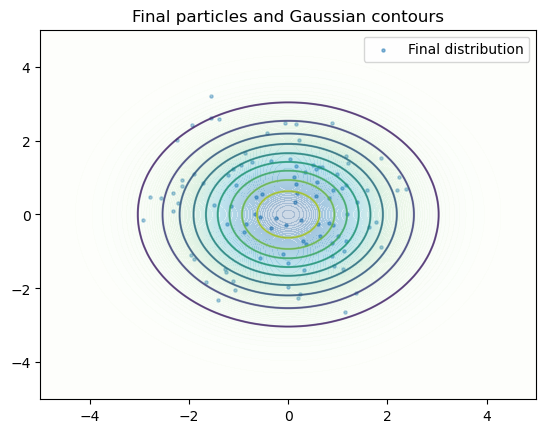

In [22]:
plt.scatter(X_fin[:, 0], X_fin[:, 1], s=5, alpha=0.5,label='Final distribution')
#plt.scatter(X0[:, 0], X0[:, 1], s=1, alpha=0.5,label = 'Initial distribution')
plt.legend()

import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax.scipy.stats import multivariate_normal

# Paramètres de la distribution
mean = jnp.zeros(2)  # Moyenne (0, 0)
cov = jnp.eye(2) * 2.0  # Matrice de covariance (2 * identité)

# Grille pour les lignes de niveau
x = jnp.linspace(-5, 5, 100)
y = jnp.linspace(-5, 5, 100)
X, Y = jnp.meshgrid(x, y)
pos = jnp.dstack((X, Y))

cf = plt.contourf(
        X, Y, Z, 
        levels=100,          # plus de niveaux pour un dégradé lisse
        cmap='GnBu', 
        alpha=0.2     # transparence du fond
    )

  # Lignes de contour par-dessus
plt.contour(
    X, Y, Z, 
    levels=10, 
    colors='black', 
    linewidths=0.8,
    alpha=0.5)
# Calcul de la densité de probabilité
Z = multivariate_normal.pdf(pos, mean, cov)

# 
plt.contour(X, Y, Z, levels=10, cmap='viridis', alpha=0.7, label='Gaussian contours')
plt.title("Final particles and Gaussian contours")
plt.legend()
plt.show()

# 4 MFNN 
Here we consider random variables linked by the relation $y,z \in \mathbb{R}$ .$y = sin(z) + \varepsilon$ where $\varepsilon$ is a gaussian noise. Consider $N$ observations pf $(z,y)$, $(Z_1,Y_1),...,(Z_N,Y_N)$. $\mathcal{L} (Q) = \frac1N \sum_{i=1}^N (Y_i - \mathbb{E}_{X \sim Q} [\psi(X,Z)])^2$. The learning function $\psi$ is a two layer neural network with parameter $X$. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mfld import MeanFieldLangevinDynamics
import jax_kernels as ker
import functions as f
import time
from variational_inference import VariationalInference

import jax.numpy as jnp
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
import random
import jax
from jax import random

In [2]:
device_name = "cpu"

In [3]:
from jax import grad, random,vmap,tree_util
from jax.flatten_util import ravel_pytree

def init_params(rng, input_dim, hidden_dim):
    rng1, rng2,rng3,rng4 = random.split(rng,4)
    params = {
        'W1': (random.uniform(rng1, (hidden_dim, input_dim))-0.5) * 10.0 ,
        'b1': 1*random.normal(rng4, (hidden_dim,)),
        'W2': (random.uniform(rng2, (1, hidden_dim))-0.5) * 10.0 ,
        'b2': 1* random.normal(rng3, (1,)) 
    }
    return params

# 

@jit
def forward(params, z):
    h = jnp.tanh(jnp.dot(params['W1'], z) + params['b1'])  # hidden layer
    y = jnp.dot(params['W2'], h) + params['b2']             # scalar output
    return y.squeeze()


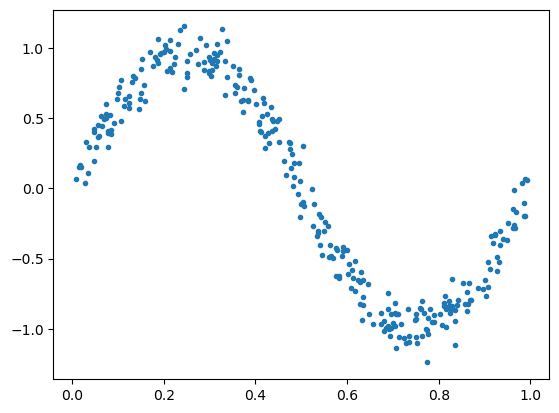

In [4]:

def generate_data(key, s, N, noise_std=0.1):
    key_z, key_noise = random.split(key)
    
    Z = random.uniform(key_z, (N, s),minval = 0,maxval=1.0)  # uniform distribution [-1,1]

    #explanation function
    def f(z):
        return jnp.sin(2 * jnp.pi * z[:,0])#, 0]) + 0.5 * Z[:, 1]**2 - jnp.exp(-Z[:, 2])

    Y_clean = f(Z)

    # noise
    noise = noise_std * random.normal(key_noise, shape=Y_clean.shape)
    Y= Y_clean + noise

    return Z, Y

N = 300
s=1 #input dimension 
key_data = random.PRNGKey(8)
Z,Y = generate_data(key_data,s, N, noise_std=0.1) # put more noise
device = jax.devices(device_name)[0]
Z, Y = jax.device_put((Z, Y), device)
plt.plot(Z,Y,".")

NameError: name 'eta' is not defined

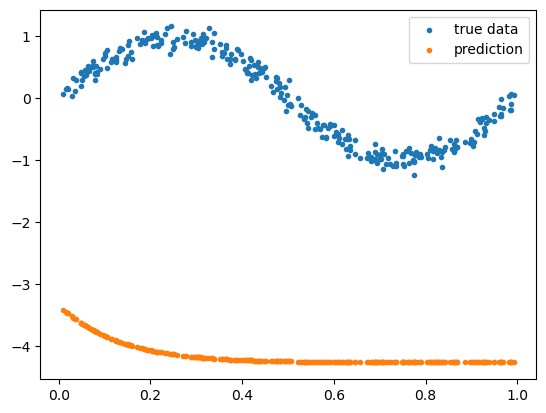

In [5]:

param_test = init_params(random.PRNGKey(4), s, 1) #input dimension, hidden dimension
plt.figure()
plt.scatter(Z,Y,label = "true data",marker = ".")
Y_hat = vmap(lambda z : forward(param_test, z))(Z)
plt.scatter(Z,Y_hat,label = "prediction",marker = ".")
plt.legend()
plt.title(r"$\eta = $ " + str(eta))

In [6]:
kernel_name = "IMQ"
c = jnp.array(1.0)
b = 3.0
def k(x,y):
    return (c**2 + (x-y).dot(x-y))**(-b)
    #return jnp.dot(x,y)

def q_0(x):
    d = jax.lax.stop_gradient(len(x))
    return jnp.exp(-jnp.dot(x,x)/(2*4)) #/ jnp.sqrt((2 * jnp.pi)**d)


key = random.PRNGKey(0)
hidden_dim = 1
params = init_params(key, s, hidden_dim)  
params = jax.device_put(params, device)
flat_params, unravel_fn = ravel_pytree(params)
d = len(flat_params)  # number of parameters
#lambd = 0.1


def esp_forward(X, z):
    E = jnp.mean(jit(vmap(lambda x : forward(unravel_fn(x), z)))(X))
    return E
gamma = 100
def L(X):  
    n = len(X)
    Esp_forward = vmap(lambda z: esp_forward(X, z))(Z)  
    return gamma * jnp.mean((Esp_forward - Y) ** 2) #+ lambd * 1/n * jnp.sum(X ** 2)

k = jit(k)
q_0 = jit(q_0)
esp_forward = jit(esp_forward)
L = jit(L)  
 
VI = VariationalInference(q_0, L, k, d) 

In [7]:
T = 2000
n = 50
eta = 1e-5


key = random.PRNGKey(14)
X_list = [init_params(random.fold_in(key, i), s, hidden_dim) for i in range(n)]
flat_X_list = [ravel_pytree(p)[0] for p in X_list] 
X0 = jnp.stack(flat_X_list)
#X0 = X_fin


key = random.PRNGKey(1)
Theta = VI.run(key,eta,T,1000)
theta_fin = Theta[-1]

W_fin = random.normal(random.PRNGKey(2), (100, d))
X_fin = VI.model(theta_fin, W_fin)

In [ ]:
# theta_fin = Theta[-5]

# W_fin = random.normal(random.PRNGKey(2), (100, d))
# X_fin = VI.model(theta_fin, W_fin)

NameError: name 'Theta' is not defined

Text(0.5, 1.0, '$\\eta = $ 1e-05')

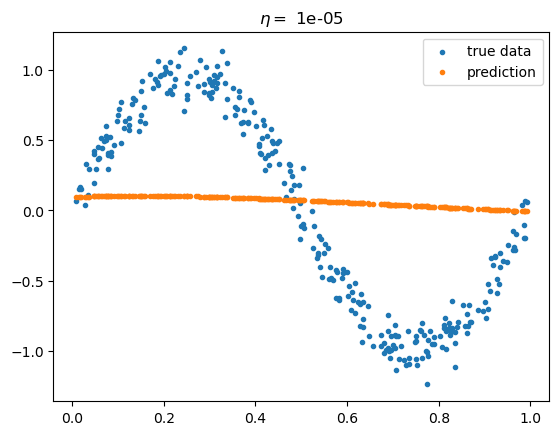

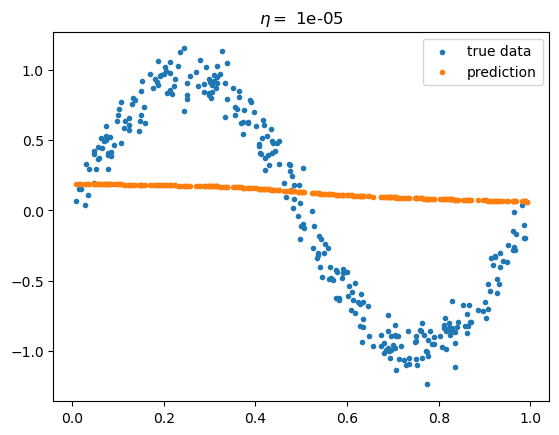

In [9]:
plt.figure()
plt.scatter(Z,Y,label = "true data",marker = ".")
Y_hat = vmap(lambda z : esp_forward(X_fin, z))(Z)
plt.scatter(Z,Y_hat,label = "prediction",marker = ".")
plt.legend()
plt.title(r"$\eta = $ " + str(eta))

plt.figure()
plt.scatter(Z,Y,label = "true data",marker = ".")
Y_hat = vmap(lambda z : esp_forward(X0, z))(Z)
plt.scatter(Z,Y_hat,label = "prediction",marker = ".")
plt.legend()
plt.title(r"$\eta = $ " + str(eta))



In [10]:
F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(VI.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

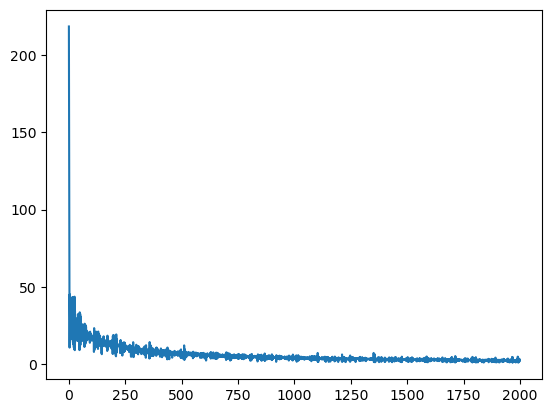

In [11]:

W0 = random.normal(random.PRNGKey(2), (1000, d))
X = jnp.array([VI.model(theta, W0) for theta in Theta])
KGD_values = jnp.zeros(T)
for it in range(T):
    KGD_values = KGD_values.at[it].set(KGD.evaluate(X[it]))
plt.plot(KGD_values, label='KGD values')

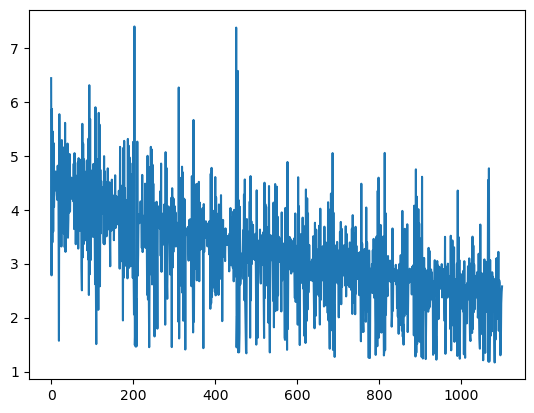

In [135]:
plt.plot(KGD_values[900:], label='KGD values')

In [64]:
KGD_values[9990:]

Array([], shape=(0,), dtype=float32)